<a href="https://colab.research.google.com/github/dev-yooillog/MAIN_QUEST/blob/main/Mini_Project6/Speed_Dating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from google.colab import drive


In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Speed Dating Data.csv'
speed_dating = pd.read_csv(file_path, encoding='unicode_escape')

In [ ]:
speed_dating.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
speed_dating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 195 entries, iid to amb5_3
dtypes: float64(174), int64(13), object(8)
memory usage: 12.5+ MB


In [ ]:
speed_dating.describe()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
count,8378.000000,8377.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,6532.000000,8378.000000,...,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
mean,283.675937,8.960248,0.500597,17.327166,1.828837,11.350919,16.872046,9.042731,9.295775,8.927668,...,7.240312,8.093357,8.388777,7.658782,7.391545,6.810020,7.615079,7.932540,7.155258,7.048611
std,158.583367,5.491329,0.500029,10.940735,0.376673,5.995903,4.358458,5.514939,5.650199,5.477009,...,1.576596,1.610309,1.459094,1.744670,1.961417,1.507341,1.504551,1.340868,1.672787,1.717988
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,4.000000,1.000000,1.000000
25%,154.000000,4.000000,0.000000,8.000000,2.000000,7.000000,14.000000,4.000000,4.000000,4.000000,...,7.000000,7.000000,8.000000,7.000000,6.000000,6.000000,7.000000,7.000000,6.000000,6.000000
50%,281.000000,8.000000,1.000000,16.000000,2.000000,11.000000,18.000000,8.000000,9.000000,8.000000,...,7.000000,8.000000,8.000000,8.000000,8.000000,7.000000,8.000000,8.000000,7.000000,7.000000
75%,407.000000,13.000000,1.000000,26.000000,2.000000,15.000000,20.000000,13.000000,14.000000,13.000000,...,8.000000,9.000000,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,8.000000,8.000000
max,552.000000,22.000000,1.000000,44.000000,2.000000,21.000000,22.000000,22.000000,22.000000,22.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [ ]:
speed_dating.rename(columns={
    'pf_o_att': 'pref_o_attractive', 'pf_o_sin': 'pref_o_sincere',
    'pf_o_int': 'pref_o_intelligence', 'pf_o_fun': 'pref_o_funny',
    'pf_o_amb': 'pref_o_ambitious', 'pf_o_sha': 'pref_o_shared_interests',
    'attr_o': 'attractive_o', 'sinc_o': 'sincere_o',
    'intel_o': 'intelligence_o', 'fun_o': 'funny_o',
    'amb_o': 'ambitious_o', 'shar_o': 'shared_interests_o',
    'attr1_1': 'attr_important', 'sinc1_1': 'sinc_important',
    'intel1_1': 'intel_important', 'fun1_1': 'fun_important',
    'amb1_1': 'amb_important', 'shar1_1': 'shar_important',
    'attr': 'attr_partner', 'sinc': 'sinc_partner',
    'intel': 'intel_partner', 'fun': 'fun_partner',
    'amb': 'amb_partner', 'shar': 'shar_partner'
}, inplace=True)

In [ ]:
num_cols = speed_dating.select_dtypes(include=[np.number]).columns
speed_dating[num_cols] = speed_dating[num_cols].fillna(-99)

In [ ]:
score_cols_to_fix = ['attractive_o', 'sincere_o', 'intelligence_o', 'funny_o', 'ambitious_o', 'shared_interests_o']
for col in score_cols_to_fix:
    speed_dating.loc[speed_dating[col] > 10, col] = 10

### Feature Engineering

In [ ]:
speed_dating = speed_dating.copy()

In [ ]:
# 나이차 계산
speed_dating['age_diff'] = abs(speed_dating['age'] - speed_dating['age_o'])
speed_dating.loc[speed_dating['age'] == -99, 'age_diff'] = -99
speed_dating.loc[speed_dating['age_o'] == -99, 'age_diff'] = -99

In [ ]:
# 인종 가중치 계산 - 같은 인종은 1, 다른 인종은 -1
speed_dating['same_race_point'] = speed_dating.apply(
    lambda row: row['imprace'] if row['race'] == row['race_o'] else -row['imprace'], axis=1
)

### 중요도 가중치

In [ ]:
pref_o_cols = ['pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests']
i_imp_cols = ['attr_important', 'sinc_important', 'intel_important', 'fun_important', 'amb_important', 'shar_important']

In [ ]:
speed_dating['pref_o_sum'] = speed_dating[pref_o_cols].replace(-99, 0).sum(axis=1)
speed_dating['i_imp_sum'] = speed_dating[i_imp_cols].replace(-99, 0).sum(axis=1)

In [ ]:
for p_col, i_col in zip(pref_o_cols, i_imp_cols):
    speed_dating[p_col] = speed_dating[p_col] * (100 / (speed_dating['pref_o_sum'] + 1e-6))
    speed_dating[i_col] = speed_dating[i_col] * (100 / (speed_dating['i_imp_sum'] + 1e-6))

In [ ]:
speed_dating['o_rating_total'] = 0.0
speed_dating['i_rating_total'] = 0.0

In [ ]:
o_score_cols = ['attractive_o', 'sincere_o', 'intelligence_o', 'funny_o', 'ambitious_o', 'shared_interests_o']
i_score_cols = ['attr_partner', 'sinc_partner', 'intel_partner', 'fun_partner', 'amb_partner', 'shar_partner']

In [ ]:
for s_col, p_col in zip(o_score_cols, pref_o_cols):
    mask = (speed_dating[s_col] != -99) & (speed_dating[p_col] != -99)
    speed_dating.loc[mask, 'o_rating_total'] += (speed_dating.loc[mask, s_col] * speed_dating.loc[mask, p_col])


In [ ]:
for s_col, p_col in zip(i_score_cols, i_imp_cols):
    mask = (speed_dating[s_col] != -99) & (speed_dating[p_col] != -99)
    speed_dating.loc[mask, 'i_rating_total'] += (speed_dating.loc[mask, s_col] * speed_dating.loc[mask, p_col])

### 최종 피터

In [ ]:
speed_dating['rating_mean'] = (2 * speed_dating['o_rating_total'] * speed_dating['i_rating_total']) / \
                              (speed_dating['o_rating_total'] + speed_dating['i_rating_total'] + 1e-6)

In [ ]:
cols_to_drop = pref_o_cols + i_imp_cols + o_score_cols + i_score_cols + ['pref_o_sum', 'i_imp_sum']
final_dating = speed_dating.drop(columns=cols_to_drop)

In [ ]:
final_dating[['match', 'age_diff', 'same_race_point', 'rating_mean']].head()

,match,age_diff,same_race_point,rating_mean
0,0,6.0,-2.0,699.428564
1,0,1.0,-2.0,694.964021
2,1,1.0,2.0,833.819233
3,1,2.0,-2.0,742.281871
4,1,3.0,-2.0,690.857135


### One Hot Encoding

In [ ]:
final_dating = pd.get_dummies(final_dating, columns=['gender', 'race', 'race_o'], drop_first=True)

In [ ]:
unnecessary_cols = ['iid', 'id', 'idg', 'condtn', 'wave', 'round',
                    'position', 'positin1','order', 'partner', 'pid',
                    'field', 'undergra', 'from', 'zipcode', 'career']

In [ ]:
cols_to_drop = [c for c in unnecessary_cols if c in final_dating.columns]
final_dating.drop(columns=cols_to_drop, inplace=True)

In [ ]:
final_dating = final_dating.fillna(-99)

In [ ]:
len(final_dating.columns)

168

In [ ]:
final_dating.head()

,match,int_corr,samerace,age_o,dec_o,like_o,prob_o,met_o,age,field_cd,...,race_1.0,race_2.0,race_3.0,race_4.0,race_6.0,race_o_1.0,race_o_2.0,race_o_3.0,race_o_4.0,race_o_6.0
0,0,0.14,0,27.0,0,7.0,4.0,2.0,21.0,1.0,...,False,False,False,True,False,False,True,False,False,False
1,0,0.54,0,22.0,0,8.0,4.0,2.0,21.0,1.0,...,False,False,False,True,False,False,True,False,False,False
2,1,0.16,1,22.0,1,10.0,10.0,1.0,21.0,1.0,...,False,False,False,True,False,False,False,False,True,False
3,1,0.61,0,23.0,1,7.0,7.0,2.0,21.0,1.0,...,False,False,False,True,False,False,True,False,False,False
4,1,0.21,0,24.0,1,8.0,6.0,2.0,21.0,1.0,...,False,False,False,True,False,False,False,True,False,False


### 데이터 분할

In [ ]:
print(final_dating.columns.tolist())

['match', 'int_corr', 'samerace', 'age_o', 'dec_o', 'like_o', 'prob_o', 'met_o', 'age', 'field_cd', 'mn_sat', 'tuition', 'imprace', 'imprelig', 'income', 'goal', 'date', 'go_out', 'career_c', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'exphappy', 'expnum', 'attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1', 'attr2_1', 'sinc2_1', 'intel2_1', 'fun2_1', 'amb2_1', 'shar2_1', 'attr3_1', 'sinc3_1', 'fun3_1', 'intel3_1', 'amb3_1', 'attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1', 'dec', 'like', 'prob', 'met', 'match_es', 'attr1_s', 'sinc1_s', 'intel1_s', 'fun1_s', 'amb1_s', 'shar1_s', 'attr3_s', 'sinc3_s', 'intel3_s', 'fun3_s', 'amb3_s', 'satis_2', 'length', 'numdat_2', 'attr7_2', 'sinc7_2', 'intel7_2', 'fun7_2', 'amb7_2', 'shar7_2', 'attr1_2', 'sinc1_2', 'intel1_2', 'fun1_2', 'amb1_2', 'shar1_2', 'attr4_2', 'sinc4_2', 'intel4_2', 'fun4_2', 'amb4_2

In [ ]:
final_features = [
    'match', 'int_corr', 'age_diff', 'same_race_point',
    'rating_mean', 'o_rating_total', 'i_rating_total', 'like', 'prob'
]

In [ ]:
dummy_cols = [col for col in final_dating.columns if col.startswith(('gender_', 'race_'))]
final_cols = final_features + dummy_cols

In [ ]:
model_df = final_dating[final_cols].copy()

In [ ]:
# 독립변수와 종속변수 분리
X = model_df.drop(columns=['match'])
y = model_df['match']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.7941527446300716

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87      1400
           1       0.41      0.59      0.48       276

    accuracy                           0.79      1676
   macro avg       0.66      0.71      0.68      1676
weighted avg       0.83      0.79      0.81      1676



### 피처 중요도

In [ ]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

In [ ]:
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

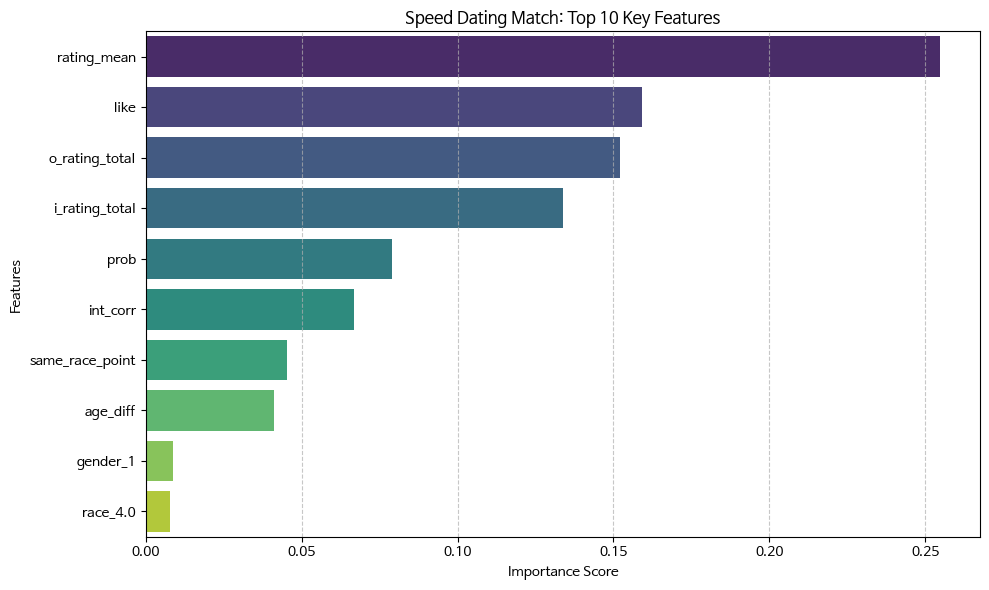

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Speed Dating Match: Top 10 Key Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 모델 저장

In [ ]:
import joblib

In [ ]:
model_filename = 'rf_speed_dating_model.joblib'
joblib.dump(rf_model, model_filename)

['rf_speed_dating_model.joblib']

In [ ]:
final_df_filename = 'speed_dating_final_processed.csv'
model_df.to_csv(final_df_filename, index=False)